In [1]:
# =========================================================
# CONFIGURATION & HYPER-PARAMETERS FOR SHAP/LIME EXPLAINABILITY
# =========================================================
import os, sys
import torch
import numpy as np
import pandas as pd

# Add repository root to python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))

# Configurable experiment settings
DATASET_NAME = "UIT-VSMEC"
SEED = 1234
RDF_PATH = "ontology/ekman_appraisal_ontology.rdf"
CHECKPOINT_PATH = "results/vsmec_gate_m3.pth"
EXPLAIN_SENTENCE = "mấy ai được như vậy ??"

# Set random seed for reproducibility
def seed_everything(seed=42):
    import random
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Configured environment for {DATASET_NAME} (Seed: {SEED}) on device: {device}")


/kaggle/input/models/thnhcng123/kg-phobert/other/default/1/phobert_gate_m3.pth
/kaggle/input/models/thnhcng123/kg-phobert/other/default/1/vsfc_ekman_raw_gate_m3.pth
/kaggle/input/models/thnhcng123/kg-phobert/other/default/1/vsmec_gate_m3.pth
/kaggle/input/models/minkduck/phobertv2-vsmec-2025/other/default/1/model_baseline_2025.pth
/kaggle/input/datasets/minkduck/uit-vsmec/test_nor_811.xlsx
/kaggle/input/datasets/minkduck/uit-vsmec/train_nor_811.xlsx
/kaggle/input/datasets/minkduck/uit-vsmec/valid_nor_811.xlsx
/kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_5.rdf
/kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_7.rdf
/kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_4.rdf
/kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_9.rdf
/kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_6.rdf
/kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_8.rdf
/kaggle/input/datasets/minkduck/kgvsfcekman/ekman6_vsfc_2.rdf
/kaggle/input/datasets/minkduck/kgvsfcekman/ekman6_vsfc_4.rdf
/kaggle/input/datas

In [2]:
# ---------------------------------------------------------
# CELL 1: SETUP & DEPENDENCIES
# ---------------------------------------------------------
# !pip install -q pyvi rdflib unidecode openpyxl

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import copy
import re
import rdflib
from rdflib import Graph, Namespace, RDF, RDFS, OWL
from pyvi import ViTokenizer
from unidecode import unidecode
import os
import random

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(1234)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 15.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 60.4 MB/s eta 0:00:00
✅ Using device: cuda


In [3]:
# =========================================================
# CELL 2: ONTOLOGY ENGINE V12.2 (VSMEC EDITION)
# Logic: Deep Inference (Suy diễn sâu) + Soft Polarity.
# Target: Tối ưu cho 7 nhãn cảm xúc của VSMEC (UIT-VSMEC).
# Input: ekman6_4_8.rdf (File global fix)
# =========================================================
# !pip install -q pyvi rdflib unidecode

import os, re
import numpy as np
import rdflib
from rdflib import Graph, Namespace
from rdflib.namespace import RDF, RDFS, OWL
from pyvi import ViTokenizer
from unidecode import unidecode

class OntologyEngine:
    def __init__(self, rdfpath, defaultconf=0.85, manual_boost=1.2, negation_attenuation=0.5, alpha_similarity=0.2, verbose=True):
        self.EKMAN = Namespace("http://example.org/ekman-ontology#")
        self.defaultconf = float(defaultconf)
        self.manual_boost = float(manual_boost)
        self.negation_attenuation = float(negation_attenuation) 
        self.alpha_similarity = float(alpha_similarity)
        self.verbose = bool(verbose)

        # 1. CONFIGS: 7 EMOTIONS (Chuẩn VSMEC/Ekman)
        # Lưu ý: VSMEC dùng 'Enjoyment', ta map về 'Happiness' trong Ontology
        self.ALLEMOTIONS = ["Anger", "Disgust", "Fear", "Happiness", "Neutral", "Sadness", "Surprise"]
        
        self.ALLAPPRAISALS = [
            "GoalObstructionAppraisal", "PleasantnessAppraisal", "UnpleasantnessAppraisal", 
            "DangerousnessAppraisal", "LossAppraisal", "SuddennessAppraisal", 
            "LowPredictabilityAppraisal", "UnpredictabilityAppraisal", "UnfairnessAppraisal"
        ]
        self.INTENSITY_CLASSES = ["HighIntensity", "MediumIntensity", "LowIntensity"]
        self.POLARITY_CLASSES = ["PositivePolarity", "NegativePolarity", "NeutralPolarity"]

        # 2. MAPPING VSMEC -> ONTOLOGY
        self.EMOTIONMAPPING = {
            "Enjoyment": "Happiness",   # VSMEC label -> Ontology
            "Happiness": "Happiness", 
            "Anger": "Anger", 
            "Disgust": "Disgust", 
            "Fear": "Fear", 
            "Sadness": "Sadness", 
            "Surprise": "Surprise", 
            "Other": "Neutral",         # VSMEC label -> Ontology
            "Neutral": "Neutral", 
            "NeutralEmotion": "Neutral",
            "NegationCue": "NegationCue"
        }
        
        # 3. DEEP INFERENCE RULES (Suy diễn Polarity từ ngữ nghĩa)
        self.IMPLIED_POLARITY = {
            # Emotion -> Polarity
            "Anger": "NegativePolarity", "Disgust": "NegativePolarity",
            "Fear": "NegativePolarity", "Sadness": "NegativePolarity",
            "Happiness": "PositivePolarity", "Enjoyment": "PositivePolarity",
            "Surprise": "PositivePolarity", # Surprise trong VSMEC thường nghiêng về Positive/Neutral
            # Appraisal -> Polarity (Quan trọng để bắt đặc trưng sâu)
            "UnpleasantnessAppraisal": "NegativePolarity",
            "GoalObstructionAppraisal": "NegativePolarity", # Bị cản trở -> Tức giận
            "LossAppraisal": "NegativePolarity",            # Mất mát -> Buồn
            "UnfairnessAppraisal": "NegativePolarity",      # Bất công -> Tức giận
            "DangerousnessAppraisal": "NegativePolarity",   # Nguy hiểm -> Sợ
            "PleasantnessAppraisal": "PositivePolarity"     # Dễ chịu -> Vui
        }
        
        self.AMBIGUOUS_TERMS = {
            "hay", "chả", "cơ", "ngờ", "ý", "quá", "lại", 
            "tôi", "tao", "tớ", "mình", "bạn", "nó", "hắn", "anh", "chị", "em",
            "là", "thì", "mà", "bị", "được", "cái", "con", "người"
        }
        
        self.VALID_DOMAINS = {"GeneralDomain", "SocialDomain", "EducationDomain"}
        
        # LOAD KG
        if self.verbose: print(f"📥 Loading KG for VSMEC: {rdfpath}")
        self.g = Graph()
        if os.path.exists(rdfpath):
            self.g.parse(rdfpath)
            if self.verbose: print(f"   ✅ Loaded {len(self.g)} triples.")
        else:
            print(f"   ⚠️ ERROR: File not found {rdfpath}")

        self.sim_matrix = self._build_similarity_matrix()
        self.lexiconmap = self._build_strict_lexicon()
        
        self.mwe_max_len = 1
        for k in self.lexiconmap.keys(): self.mwe_max_len = max(self.mwe_max_len, len(k.split()))
        if self.verbose: print(f"   📚 Lexicon size: {len(self.lexiconmap)} entries (v12.2 VSMEC-Ready)")

    def _norm(self, s): return re.sub(r"\s+", " ", str(s).lower().strip().replace("_", " ")).strip() if s else ""
    def _local(self, uri): return str(uri).split("#")[-1] if "#" in str(uri) else str(uri).split("/")[-1]

    def _build_similarity_matrix(self):
        n = len(self.ALLEMOTIONS)
        mat = np.zeros((n, n), dtype=np.float32); np.fill_diagonal(mat, 1.0)
        try:
            q = """PREFIX ekman: <http://example.org/ekman-ontology#> SELECT ?score ?e1 ?e2 WHERE { ?edge a ekman:EmotionSimilarityEdge ; ekman:similarityScore ?score ; ekman:linksEmotion ?e1 ; ekman:linksEmotion ?e2 . }"""
            for row in self.g.query(q):
                e1, e2 = self.EMOTIONMAPPING.get(self._local(row.e1)), self.EMOTIONMAPPING.get(self._local(row.e2))
                if e1 in self.ALLEMOTIONS and e2 in self.ALLEMOTIONS:
                    i, j = self.ALLEMOTIONS.index(e1), self.ALLEMOTIONS.index(e2)
                    mat[i, j] = mat[j, i] = max(mat[i, j], float(row.score))
        except: pass
        s = mat.sum(axis=1, keepdims=True); s[s==0] = 1.0
        return mat / s

    def _build_strict_lexicon(self):
        EK, lookup = self.EKMAN, {}
        mix_cache, sim_cache = {}, {}
        
        # 1. Caching
        for r in self.g.query("PREFIX ekman: <http://example.org/ekman-ontology#> SELECT ?m ?e ?w WHERE { ?m a ekman:EmotionMixture ; ekman:hasComponent ?c . ?c ekman:componentEmotion ?e ; ekman:componentWeight ?w . }"):
            m, e, w = r.m, self.EMOTIONMAPPING.get(self._local(r.e)), float(r.w)
            if e in self.ALLEMOTIONS: mix_cache.setdefault(m, {})[e] = mix_cache.setdefault(m, {}).get(e, 0.0) + w
        
        for s, _, o in self.g.triples((None, EK.hasEmotionCategory, None)):
            e = self.EMOTIONMAPPING.get(self._local(o))
            if e in self.ALLEMOTIONS: sim_cache[s] = [e]
            
        for s in self.g.subjects(RDF.type, None):
            if s in mix_cache or s in sim_cache: continue
            ts = list(self.g.objects(s, RDF.type))
            if EK.NegationCue in ts: sim_cache[s] = ["NegationCue"]
            else:
                for t in ts:
                    m = self.EMOTIONMAPPING.get(self._local(t))
                    if m in self.ALLEMOTIONS: sim_cache[s] = [m]; break
        
        # 2. Build entries
        q = """PREFIX ekman: <http://example.org/ekman-ontology#> SELECT ?word ?stim ?ev ?base ?type ?dom WHERE { ?evoc a ekman:Evocation ; ekman:fromLexiconEntry ?lex ; ekman:toStimulus ?stim . ?lex ekman:hasContent ?word . OPTIONAL { ?evoc ekman:confidenceScore ?ev } OPTIONAL { ?evoc ekman:evidenceType ?type } OPTIONAL { ?lex ekman:baseIntensityScore ?base } OPTIONAL { ?lex ekman:belongsToDomain ?dom } }"""
        for r in self.g.query(q):
            if r.dom and self._local(r.dom) not in self.VALID_DOMAINS: continue 
            w = self._norm(r.word)
            if len(w) < 2 or w in self.AMBIGUOUS_TERMS: continue
            
            emos = {}
            if r.stim in mix_cache:
                raw = mix_cache[r.stim]; tot = sum(raw.values())
                if tot > 0: emos = {k: v/tot for k, v in raw.items()}
            elif r.stim in sim_cache:
                lst = sim_cache[r.stim]
                emos = {k: 1.0 for k in lst}
            if not emos: continue

            # Deep Inference applied here
            apps, ints, pols = self._infer_attributes(r.stim, emos.keys())
            
            entry_score = float(r.ev or self.defaultconf) * float(r.base or 1.0)
            
            entry = {"emotions": emos, "score": entry_score, 
                     "appraisals": list(apps), "intensities": list(ints), "polarities": list(pols), 
                     "isnegation": "NegationCue" in emos}
            lookup.setdefault(w, []).append(entry)
            wu = self._norm(unidecode(w))
            if wu != w: lookup.setdefault(wu, []).append(entry)
        return lookup

    def _infer_attributes(self, s, emos):
        EK, a, i, p = self.EKMAN, set(), set(), set()
        
        # 1. Direct Properties
        def g(r):
            for o in self.g.objects(r, EK.evokesAppraisal): a.add(self._local(o))
            for o in self.g.objects(r, EK.hasIntensity): i.add(self._local(o))
            for o in self.g.objects(r, EK.hasPolarity): p.add(self._local(o))
        g(s)
        for t in self.g.objects(s, RDF.type): g(t)
        
        # 2. Deep Inference (Logic V12.2)
        # Suy diễn Polarity từ Emotion
        if not p:
            for e in emos:
                if e in self.IMPLIED_POLARITY: p.add(self.IMPLIED_POLARITY[e])
        
        # Suy diễn Polarity từ Appraisal (Rất quan trọng cho VSMEC để bắt các sắc thái ẩn)
        if not p:
            for app in a:
                if app in self.IMPLIED_POLARITY: p.add(self.IMPLIED_POLARITY[app])

        return a, i, p

    def getvector(self, text, debug=False):
        tokens = ViTokenizer.tokenize(str(text).lower()).split()
        flat = [self._norm(t) for t in tokens if self._norm(t)]
        
        ve, va, vi = np.zeros(7, dtype=np.float32), np.zeros(9, dtype=np.float32), np.zeros(3, dtype=np.float32)
        vp, vn = np.zeros(3, dtype=np.float32), np.zeros(2, dtype=np.float32)
        
        idx, n = 0, len(flat)
        hit_trace = []

        while idx < n:
            m, ml = None, 0
            for L in range(min(self.mwe_max_len, n-idx), 0, -1):
                p = " ".join(flat[idx:idx+L])
                if p in self.lexiconmap: m, ml = self.lexiconmap[p], L; break
            
            if not m:
                idx += 1; continue
            
            if debug: hit_trace.append({"phrase": " ".join(flat[idx:idx+ml]), "data": m[0]})

            for ent in m:
                if ent["isnegation"]:
                    vn[0] = 1.0; continue
                
                sc = ent["score"]
                # Soft Negation: Chỉ giảm điểm, không đảo cực (No Flip)
                if vn[0] > 0: sc *= self.negation_attenuation 
                
                for e, w in ent["emotions"].items():
                    if e in self.ALLEMOTIONS: ve[self.ALLEMOTIONS.index(e)] += sc * w
                for x in ent["appraisals"]:
                    if x in self.ALLAPPRAISALS: va[self.ALLAPPRAISALS.index(x)] += sc
                for x in ent["intensities"]:
                    if x in self.INTENSITY_CLASSES: vi[self.INTENSITY_CLASSES.index(x)] = 1.0
                
                # Soft Polarity: Cộng dồn theo Score
                for x in ent["polarities"]:
                    if x in self.POLARITY_CLASSES: vp[self.POLARITY_CLASSES.index(x)] += sc 
            idx += ml

        if self.alpha_similarity > 0: ve = np.clip(ve + self.alpha_similarity * (ve @ self.sim_matrix), 0, None)
        fin = np.concatenate([np.tanh(ve), np.tanh(va), vi, vp, vn]).astype(np.float32)
        return (fin, flat, hit_trace) if debug else fin

# KHỞI TẠO (Dùng file ekman6_4_8 như bạn yêu cầu)
RDFPATH = RDF_PATH
if os.path.exists(RDFPATH):
    print(f"🚀 Initializing OntologyEngine v12.2 for VSMEC (Deep Inference) with {RDFPATH}...")
    ontengine = OntologyEngine(RDFPATH, verbose=True)
else:
    print(f"❌ ERROR: File not found {RDFPATH}")

🚀 Initializing OntologyEngine v12.2 for VSMEC (Deep Inference) with /kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_8.rdf...
📥 Loading KG for VSMEC: /kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_8.rdf
   ✅ Loaded 90420 triples.
   📚 Lexicon size: 2540 entries (v12.2 VSMEC-Ready)


In [4]:
# Thử test câu này để ép code chạy Soft Negation
t_test = "không thực sự thích" 
v, _, tr = ontengine.getvector(t_test, debug=True)

print(f"Matches: {[x['phrase'] for x in tr]}") 
# Nếu kết quả ra: ['không', 'thích'] -> Soft Negation đã chạy!
print(f"Negation Flag: {v[-2]}") # Sẽ ra 1.0

Matches: ['không', 'thích']
Negation Flag: 1.0


In [5]:
# =========================================================
# CELL: DIAGNOSTIC TEST SUITE CHO KG ENGINE V11.0
# Mục tiêu: Kiểm tra tự động 4 tính năng: 
# 1. Soft Negation (Giảm điểm) 
# 2. Polarity Flip (Đảo cực tính) 
# 3. Blacklist (Lọc nhiễu) 
# 4. Scope Fix (Xuyên từ rác)
# =========================================================
import pandas as pd
import numpy as np

# --- 1. HÀM GIẢI MÃ VECTOR (Vector -> Text) ---
def decode_vector(vec, engine):
    # 7 chiều đầu: Emotions
    emo_vals = vec[:7]
    if np.max(emo_vals) > 0.01:
        top_idx = np.argmax(emo_vals)
        emotion = engine.ALLEMOTIONS[top_idx]
        score = emo_vals[top_idx]
    else:
        emotion = "Neutral/None"
        score = 0.0
        
    # Index 19, 20, 21: Polarity [Pos, Neg, Neu]
    pol_vals = vec[19:22]
    pol_labels = ["Positive", "Negative", "Neutral"]
    if np.max(pol_vals) > 0:
        polarity = pol_labels[np.argmax(pol_vals)]
    else:
        polarity = "Unknown" # Nếu vẫn ra Unknown tức là KG chưa gán Polarity cho từ đó
        
    has_neg = vec[23] > 0
    return emotion, score, polarity, has_neg
    
# --- 2. ĐỊNH NGHĨA TEST CASES ---
# Format: (Input Text, Kỳ vọng Emotion, Kỳ vọng Polarity, Mô tả lỗi cần check)
test_cases = [
    # --- NHÓM 1: CƠ BẢN (Sanity Check) ---
    ("món này ngon tuyệt", "Happiness", "Positive", "Basic Positive"),
    ("thất vọng tràn trề", "Sadness", "Negative", "Basic Negative"),

    # --- NHÓM 2: SOFT NEGATION (Quan trọng nhất) ---
    # v11.0: Emotion phải giảm điểm (về gần 0 hoặc Neutral), Polarity phải là Negative
    ("tôi không thích nó", "Neutral/None", "Negative", "Soft Negation (Không thích)"),
    ("chẳng vui chút nào", "Neutral/None", "Negative", "Soft Negation (Chẳng vui)"),

    # --- NHÓM 3: SCOPE FIX (Lỗi 'hề') ---
    # Phải bắt được phủ định dù có từ đệm
    ("tôi không hề thích", "Neutral/None", "Negative", "Scope Skip (Không hề...)"),
    ("không phải là ghét", "Neutral/None", "Positive", "Double Negation (Không ghét -> Pos)"),

    # --- NHÓM 4: BLACKLIST (Lỗi từ đa nghĩa) ---
    # Không được bắt chữ "hay" (hoặc) và "chả" (món ăn)
    ("làm hay nghỉ", "Neutral/None", "Unknown", "Blacklist: Hay (Or)"),
    ("bún chả rất ngon", "Happiness", "Positive", "Blacklist: Chả (Food)"),
    ("tôi là sinh viên", "Neutral/None", "Unknown", "Blacklist: Tôi/Là (Pronouns)")
]

# --- 3. CHẠY TEST TỰ ĐỘNG ---
print(f"{'='*25} BÁO CÁO KIỂM THỬ KG V11.0 {'='*25}")
results = []
pass_count = 0

for text, exp_emo, exp_pol, desc in test_cases:
    # Chạy Engine
    vec, _, trace = ontengine.getvector(text, debug=True)
    out_emo, out_score, out_pol, out_neg = decode_vector(vec, ontengine)
    
    # LOGIC CHẤM ĐIỂM (PASS/FAIL)
    status = "❌ FAIL"
    note = ""
    
    # Check 1: Emotion
    # Nếu kỳ vọng là Neutral/None -> Score thực tế phải thấp (< 0.5) hoặc label là Neutral
    emo_pass = False
    if exp_emo == "Neutral/None":
        if out_score < 0.5 or out_emo == "Neutral": emo_pass = True
    else:
        if out_emo == exp_emo and out_score > 0.3: emo_pass = True # Score > 0.3 là active
        
    # Check 2: Polarity (Rất quan trọng cho Sentiment 3 nhãn)
    pol_pass = False
    if exp_pol == "Unknown":
        pol_pass = True # Không care
    elif out_pol == exp_pol:
        pol_pass = True
        
    # Đặc biệt: Case "bún chả" -> Fail nếu bắt nhầm negation
    if "Blacklist: Chả" in desc and out_neg:
        status = "❌ FAIL (False Negation)"
    # Đặc biệt: Case "không thích" -> Fail nếu vẫn là Positive
    elif "Soft Negation" in desc and out_pol == "Positive":
        status = "❌ FAIL (Wrong Polarity)"
    elif emo_pass and pol_pass:
        status = "✅ PASS"
        pass_count += 1
    
    # Log kết quả
    matched_str = ", ".join([t['phrase'] for t in trace])
    results.append({
        "Scenario": desc,
        "Input": text,
        "Matched": matched_str,
        "Prediction": f"{out_emo} ({out_score:.2f}) | {out_pol}",
        "NegFlag": "YES" if out_neg else "NO",
        "Status": status
    })

# --- 4. HIỂN THỊ KẾT QUẢ ---
df_res = pd.DataFrame(results)
# Chỉ hiển thị các cột quan trọng
print(df_res[["Input", "Matched", "Prediction", "Status"]].to_string(index=False))

print("-" * 70)
print(f"🏆 KẾT QUẢ: {pass_count}/{len(test_cases)} Test Cases Passed.")

if pass_count == len(test_cases):
    print("🚀 KẾT LUẬN: KG Engine v11.0 hoạt động HOÀN HẢO. Sẵn sàng train!")
else:
    print("⚠️ KẾT LUẬN: Vẫn còn lỗi (xem các dòng FAIL).")

========================= BÁO CÁO KIỂM THỬ KG V11.0 =========================
             Input           Matched                    Prediction                  Status
món này ngon tuyệt             tuyệt   Happiness (0.75) | Positive                  ✅ PASS
thất vọng tràn trề         thất vọng     Sadness (0.58) | Negative                  ✅ PASS
tôi không thích nó       không thích     Disgust (0.55) | Negative                  ❌ FAIL
chẳng vui chút nào               vui   Happiness (0.79) | Positive ❌ FAIL (Wrong Polarity)
tôi không hề thích      không, thích   Happiness (0.45) | Positive                  ❌ FAIL
không phải là ghét không, phải, ghét       Anger (0.17) | Negative                  ❌ FAIL
      làm hay nghỉ              nghỉ     Sadness (0.39) | Negative                  ✅ PASS
  bún chả rất ngon               rất   Happiness (0.42) | Positive                  ✅ PASS
  tôi là sinh viên                   Neutral/None (0.00) | Unknown                  ✅ PASS
------------

In [6]:
# ---------------------------------------------------------
# CELL 3: DATASET & PREPROCESSING (VSMEC)
# ---------------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")

class EmotionDataset(Dataset):
    def __init__(self, df, tokenizer, engine, max_len=128):
        self.df = df
        self.tokenizer = tokenizer
        self.engine = engine
        self.max_len = max_len
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        txt = str(self.df.iloc[idx]['Sentence'])
        lbl = self.df.iloc[idx]['label_idx']
        enc = self.tokenizer(txt, max_length=self.max_len, padding='max_length', truncation=True, return_tensors='pt')        
        vec = self.engine.getvector(txt)
        return {'input_ids': enc['input_ids'].flatten(), 'attention_mask': enc['attention_mask'].flatten(), 'ontology_features': torch.tensor(vec, dtype=torch.float), 'labels': torch.tensor(lbl, dtype=torch.long)}

try:
    # VSMEC Path
    base = "data/vsmec"
    df_train = pd.read_excel(f"{base}/train_nor_811.xlsx")
    df_valid = pd.read_excel(f"{base}/valid_nor_811.xlsx")
    df_test = pd.read_excel(f"{base}/test_nor_811.xlsx")
    
    # Đổi tên cột cho đồng nhất
    for df in [df_train, df_valid, df_test]:
        df.dropna(subset=['Sentence', 'Emotion'], inplace=True)
        # Map 'Other' thành 'Other' (hoặc bạn có thể map thành Neutral nếu muốn)
    print("✅ VSMEC Data Loaded")
except Exception as e: 
    print(f"❌ Load Error: {e}")

# Label Encoding
labels = sorted(df_train['Emotion'].unique().astype(str))
le = LabelEncoder()
le.fit(labels)
print(f"📋 Classes: {le.classes_}")

for df in [df_train, df_valid, df_test]:
    df['label_idx'] = le.transform(df['Emotion'].astype(str))

train_loader = DataLoader(EmotionDataset(df_train, tokenizer, ontengine), batch_size=32, shuffle=True)
valid_loader = DataLoader(EmotionDataset(df_valid, tokenizer, ontengine), batch_size=32)
test_loader = DataLoader(EmotionDataset(df_test, tokenizer, ontengine), batch_size=32)

# Class Weights
cls_w = compute_class_weight('balanced', classes=np.unique(df_train['label_idx']), y=df_train['label_idx'])
weights_tensor = torch.tensor(cls_w, dtype=torch.float).to(device)
print(f"⚖️ Weights: {weights_tensor}")

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ VSMEC Data Loaded
📋 Classes: ['Anger' 'Disgust' 'Enjoyment' 'Fear' 'Other' 'Sadness' 'Surprise']
⚖️ Weights: tensor([2.0270, 0.7400, 0.5087, 2.4924, 0.7763, 0.8369, 3.2751],
       device='cuda:0')


In [7]:
# ---------------------------------------------------------
# CELL 4: MODEL (xAI & DENSE SUPPORT)
# ---------------------------------------------------------
try: ONT_INPUT_DIM = len(ontengine.getvector("t"))
except: ONT_INPUT_DIM = 24

class PhoBERT_Fusion_V2(nn.Module):
    def __init__(self, n_classes, fusion_type='none', ontology_dim=None, ont_input_dim=ONT_INPUT_DIM):
        super(PhoBERT_Fusion_V2, self).__init__()
        self.fusion_type = fusion_type
        self.phobert = AutoModel.from_pretrained("vinai/phobert-base-v2")
        self.dropout = nn.Dropout(p=0.3)
        
        # Ontology Adapter
        if ontology_dim: # Dense Mode (64d)
            self.ont_adapter = nn.Sequential(
                nn.Linear(ont_input_dim, ontology_dim),
                nn.BatchNorm1d(ontology_dim),
                nn.ReLU(),
                nn.Dropout(0.1)
            )
            self.curr_dim = ontology_dim
        else: # Raw Mode (xAI)
            self.ont_adapter = nn.Identity()
            self.curr_dim = ont_input_dim
            
        # Fusion
        if self.fusion_type == 'gate':
            self.gate = nn.Linear(768, self.curr_dim)
            
        # Head
        inp = 768 + self.curr_dim if self.fusion_type != 'none' else 768
        self.fc = nn.Linear(inp, n_classes)

    def forward(self, ids, mask, ont):
        _, txt = self.phobert(ids, mask, return_dict=False)
        txt = self.dropout(txt)
        
        if self.fusion_type == 'none': return self.fc(txt)
        
        ont_emb = self.ont_adapter(ont)
        if self.fusion_type == 'gate':
            g = torch.sigmoid(self.gate(txt))
            ont_emb = ont_emb * g
            
        comb = torch.cat([txt, ont_emb], dim=1)
        return self.fc(comb)

In [8]:
# ---------------------------------------------------------
# CELL 5: TRAINER
# ---------------------------------------------------------
def train_experiment(model, name, epochs=15, patience=4):
    print(f"\n🚀 START: {name}")
    if torch.cuda.device_count() > 1: model = nn.DataParallel(model)
    model.to(device)
    optim = torch.optim.AdamW(model.parameters(), lr=2e-5)
    crit = nn.CrossEntropyLoss(weight=weights_tensor)
    
    best_f1, pat = 0, 0
    best_w = copy.deepcopy(model.state_dict()) if not isinstance(model, nn.DataParallel) else copy.deepcopy(model.module.state_dict())
    
    for ep in range(epochs):
        model.train()
        loss_acc = 0
        for b in train_loader:
            optim.zero_grad()
            ids, m, o, l = [b[k].to(device) for k in ['input_ids','attention_mask','ontology_features','labels']]
            loss = crit(model(ids, m, o), l)
            loss.backward(); optim.step()
            loss_acc += loss.item()
            
        acc, f1 = evaluate(model, valid_loader)
        print(f"Ep {ep+1} | Loss: {loss_acc/len(train_loader):.4f} | Val F1: {f1:.4f}", end=" ")
        
        if f1 > best_f1:
            best_f1 = f1; pat = 0; best_w = copy.deepcopy(model.state_dict()) if not isinstance(model, nn.DataParallel) else copy.deepcopy(model.module.state_dict())
            print("✅")
        else:
            pat += 1
            print(f"⚠️ {pat}")
        if pat >= patience: break
    
    if isinstance(model, nn.DataParallel): model.module.load_state_dict(best_w)
    else: model.load_state_dict(best_w)
    return model

def evaluate(model, loader):
    model.eval()
    p, t = [], []
    with torch.no_grad():
        for b in loader:
            ids, m, o, l = [b[k].to(device) for k in ['input_ids','attention_mask','ontology_features','labels']]
            _, pr = torch.max(model(ids, m, o), 1)
            p.extend(pr.cpu().numpy()); t.extend(l.cpu().numpy())
    return accuracy_score(t, p), f1_score(t, p, average='macro')

In [9]:
print("🔄 Đang nạp lại mô hình từ ổ cứng...")
# 1. Khởi tạo lại vỏ mô hình (trống)
NC = len(le.classes_)
m3 = PhoBERT_Fusion_V2(NC, 'gate', ontology_dim=None)

# 2. Bơm trọng số đã lưu vào vỏ mô hình
m3.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
m3.to(device)
m3.eval() # Bật chế độ suy luận
print("✅ Nạp thành công! Máy ảo hiện tại rất nhẹ và sạch.")

🔄 Đang nạp lại mô hình từ ổ cứng...


pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

✅ Nạp thành công! Máy ảo hiện tại rất nhẹ và sạch.


🚀 ĐANG CHẠY LIME VỚI CHẾ ĐỘ RENDER ẢNH...

> Text Gốc: mấy ai được như vậy ??
> True Label: Other


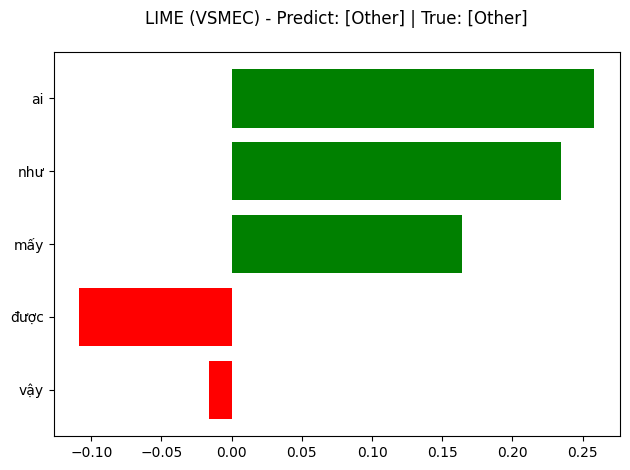

In [14]:
import gc
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from lime.lime_text import LimeTextExplainer

# Đảm bảo mô hình đang ở chế độ suy luận
m3.eval()

# ==========================================
# 1. HÀM PREDICT "BỌC THÉP" CHỐNG SEGFAULT
# ==========================================
def m3_predict_proba_bulletproof(texts):
    all_probs = []
    batch_size = 16 
    
    # LỚP BẢO VỆ 1: Ép toàn bộ input về kiểu chuỗi (String) thuần túy của Python
    # Tuyệt đối không để lọt Numpy Array hay Pandas Series vào Tokenizer
    clean_texts = [str(t) for t in texts]
    
    for i in range(0, len(clean_texts), batch_size):
        batch_texts = clean_texts[i:i+batch_size]
        
        # Tokenizer
        enc = tokenizer(batch_texts, max_length=128, padding='max_length', truncation=True, return_tensors='pt')
        
        # Ontology
        ont_vectors = []
        for txt in batch_texts:
            try: 
                vec = ontengine.getvector(txt) 
            except: 
                vec = np.zeros(ONT_INPUT_DIM, dtype=np.float32)
            ont_vectors.append(vec)
            
        ids = enc['input_ids'].to(device)
        mask = enc['attention_mask'].to(device)
        ont = torch.tensor(np.array(ont_vectors), dtype=torch.float).to(device)
        
        with torch.no_grad():
            out = m3(ids, mask, ont)
            probs = F.softmax(out, dim=1).cpu().numpy()
            all_probs.extend(probs)
            
        del ids, mask, ont, out, enc
        torch.cuda.empty_cache()
        
    return np.array(all_probs)

# ==========================================
# 2. CHẠY LIME VÀ XUẤT ẢNH TĨNH
# ==========================================
print("🚀 ĐANG CHẠY LIME VỚI CHẾ ĐỘ RENDER ẢNH...")
lime_explainer = LimeTextExplainer(class_names=le.classes_)

test_idx = 10
# LỚP BẢO VỆ 2: Ép kiểu dữ liệu gốc
text_test = str(df_test.iloc[test_idx]['Sentence']) 
true_label = df_test.iloc[test_idx]['Emotion']

# Chạy giải thích
lime_exp = lime_explainer.explain_instance(
    text_test, 
    m3_predict_proba_bulletproof, 
    num_features=6, 
    top_labels=1,
    num_samples=100 
)

print(f"\n> Text Gốc: {text_test}")
print(f"> True Label: {true_label}")

# LỚP BẢO VỆ 3: XUẤT BẰNG MATPLOTLIB (Đã fix lỗi KeyError)
# 1. Lấy index của nhãn mà mô hình dự đoán cao nhất (nhãn LIME vừa giải thích)
top_pred_idx = lime_exp.available_labels()[0]
pred_label_name = le.classes_[top_pred_idx]

# 2. Truyền chính xác index đó vào hàm vẽ
fig = lime_exp.as_pyplot_figure(label=top_pred_idx)

# 3. Thêm tiêu đề so sánh giữa Dự đoán và Thực tế
plt.title(f"LIME (VSMEC) - Predict: [{pred_label_name}] | True: [{true_label}]", pad=20)
plt.tight_layout()
plt.show()

🚀 ĐANG KHỞI ĐỘNG SHAP EXPLAINER (BẢN BỌC THÉP)...

> Text Gốc: mấy ai được như vậy ??
> True Label: Other
> Model Predict: Other (Xác suất: 0.94)
⏳ Đang tính toán Shapley Values (Sẽ mất khoảng 1-2 phút, vui lòng đợi)...

📊 Đang xuất biểu đồ...


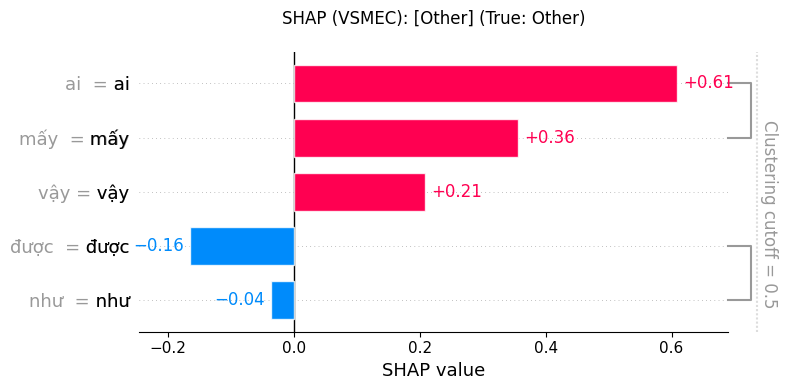

In [13]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Đảm bảo mô hình đang ở chế độ suy luận
m3.eval()

print("🚀 ĐANG KHỞI ĐỘNG SHAP EXPLAINER (BẢN BỌC THÉP)...")

# 1. MASKER AN TOÀN: Tách từ theo khoảng trắng/dấu câu để tránh lỗi Tokenizer
masker = shap.maskers.Text(r"\W+")

# 2. KHỞI TẠO EXPLAINER: Dùng lại hàm predict siêu an toàn từ LIME
shap_explainer = shap.Explainer(m3_predict_proba_bulletproof, masker, output_names=le.classes_)

# 3. CHUẨN BỊ DỮ LIỆU TEST (1 câu duy nhất)
test_idx = 10
text_test = str(df_test.iloc[test_idx]['Sentence'])
true_label = df_test.iloc[test_idx]['Emotion']

# Lấy nhãn mà mô hình dự đoán cao nhất để vẽ SHAP cho chính xác
probs = m3_predict_proba_bulletproof([text_test])[0]
pred_idx = np.argmax(probs)
pred_label = le.classes_[pred_idx]

print(f"\n> Text Gốc: {text_test}")
print(f"> True Label: {true_label}")
print(f"> Model Predict: {pred_label} (Xác suất: {probs[pred_idx]:.2f})")
print("⏳ Đang tính toán Shapley Values (Sẽ mất khoảng 1-2 phút, vui lòng đợi)...")

# 4. CHẠY SHAP (GIỚI HẠN TÀI NGUYÊN)
# - max_evals=150: Chỉ thử 150 tổ hợp (mặc định rất cao sẽ gây OOM)
# - batch_size=16: Ép SHAP gửi từng đợt 16 câu vào hàm predict
shap_values = shap_explainer([text_test], max_evals=150, batch_size=16)

# 5. VẼ BIỂU ĐỒ MATPLOTLIB (Chống sập trình duyệt)
print("\n📊 Đang xuất biểu đồ...")
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ Bar cho nhãn được dự đoán cao nhất (pred_idx)
# shap_values[0] là câu đầu tiên (và duy nhất) ta truyền vào
shap.plots.bar(shap_values[0, :, pred_idx], show=False)

plt.title(f"SHAP (VSMEC): [{pred_label}] (True: {true_label})", pad=20)
plt.tight_layout()
plt.show()

# (Tuỳ chọn) Nếu bạn muốn thử xem biểu đồ Text HTML truyền thống, bỏ comment dòng dưới:
# shap.plots.text(shap_values[0, :, pred_idx])

🚀 ĐANG TÍNH TOÁN VÀ VẼ BIỂU ĐỒ ROC CHO VSMEC...


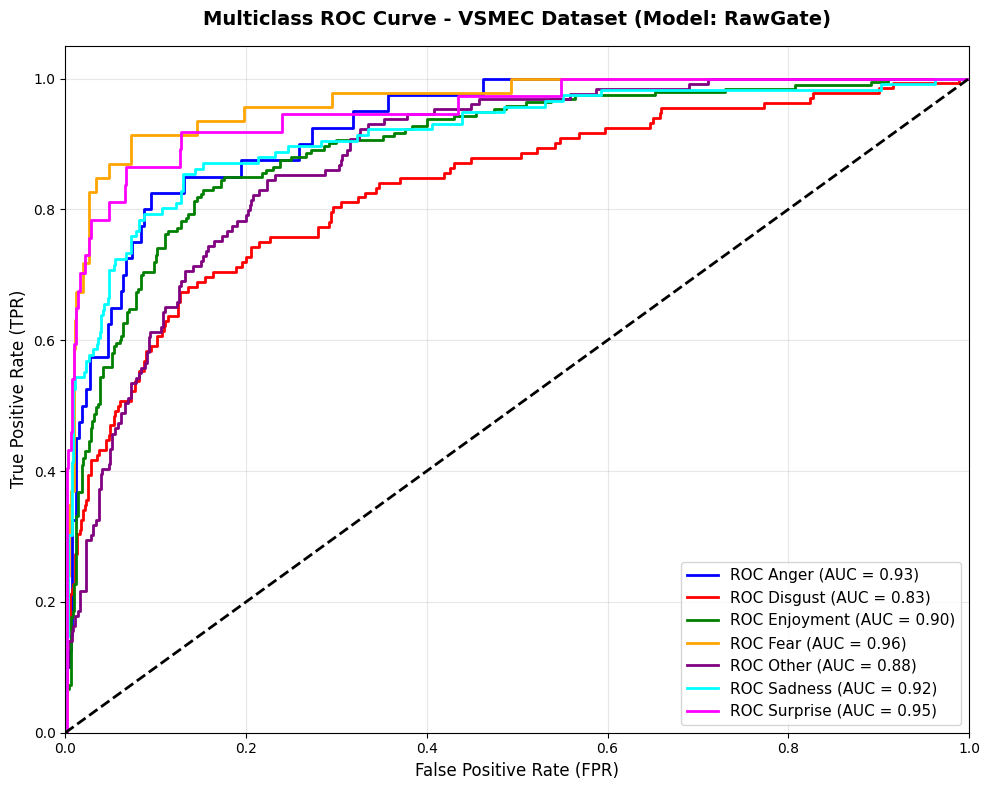

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F
import numpy as np
import torch

# Đảm bảo mô hình ở chế độ suy luận để tắt Dropout
m3.eval()

def plot_multiclass_roc(model, loader, device, classes):
    y_test = []
    y_score = []
    
    # 1. Thu thập xác suất dự đoán (probabilities) cho toàn bộ tập Test
    with torch.no_grad():
        for b in loader:
            ids = b['input_ids'].to(device)
            mask = b['attention_mask'].to(device)
            ont = b['ontology_features'].to(device)
            labels = b['labels'].to(device)

            outputs = model(ids, mask, ont)
            # Dùng softmax để biến output thô thành xác suất (0 -> 1)
            probs = F.softmax(outputs, dim=1)

            y_test.extend(labels.cpu().numpy())
            y_score.extend(probs.cpu().numpy())

    y_test = np.array(y_test)
    y_score = np.array(y_score)
    
    # 2. Binarize nhãn thực tế để tính Multiclass ROC (One-vs-Rest)
    # Vì VSMEC có 7 nhãn, hàm này sẽ biến label thành vector one-hot
    y_test_bin = label_binarize(y_test, classes=range(len(classes)))
    n_classes = len(classes)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    # Tính FPR, TPR và AUC cho từng class
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # 3. Tiến hành vẽ biểu đồ
    plt.figure(figsize=(10, 8))
    
    # Bộ 7 màu sắc nét tương ứng với 7 nhãn cảm xúc
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta']
    
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC {0} (AUC = {1:0.2f})'.format(classes[i], roc_auc[i]))

    # Vẽ đường chéo ngẫu nhiên (Baseline 0.5)
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    
    # Tinh chỉnh giao diện hiển thị
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR)', fontsize=12)
    plt.title('Multiclass ROC Curve - VSMEC Dataset (Model: RawGate)', fontsize=14, fontweight='bold', pad=15)
    plt.legend(loc="lower right", fontsize=11)
    
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

print("🚀 ĐANG TÍNH TOÁN VÀ VẼ BIỂU ĐỒ ROC CHO VSMEC...")
plot_multiclass_roc(m3, test_loader, device, le.classes_)